INFO:root:Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file
2026-02-03T12:51:54.536+00:00 INFO : Reading injection file


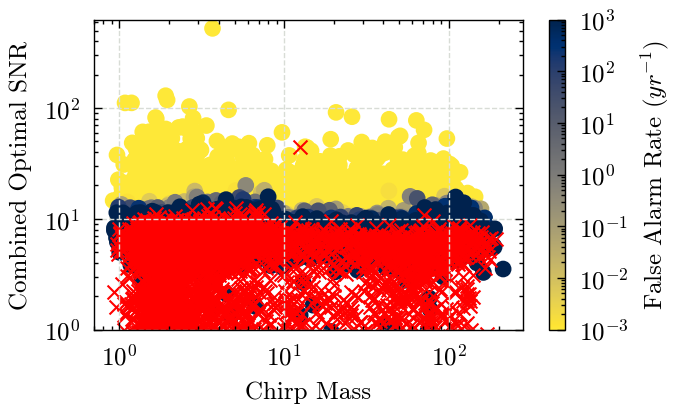

In [13]:
# Plot found and missed injections (exact CLI reproduction)

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import logging
import pycbc.pnutils
import pycbc.results
from pycbc import init_logging
from pycbc.detector import Detector
plt.style.use("paper.mplstyle")

# -------------------------
# Parameters (from CLI)
# -------------------------

injection_file = "/home/saml.insley/o3/analysis/pycbc/a35_flow/output/allinj/H1L1V1-HDFINJFIND_ALL_INJECTIONS-1265132995-614458.hdf"
output_file = "../Plots/Found_missed"

axis_type = "mchirp"
distance_type = "comb_optimal_snr"

far_type = "exclusive"
gradient_far = True
ifar_limits = (0.001, 1000)

log_x = True
log_distance = True
missed_on_top = True

colormap = "cividis_r"
verbose = 1

# -------------------------
# Logging
# -------------------------

init_logging(verbose)
logging.info("Reading injection file")

# -------------------------
# Load file
# -------------------------

f = h5py.File(injection_file, "r")

time = f['injections/tc'][:]
found = f['found_after_vetoes/injection_index'][:]
missed = f['missed/after_vetoes'][:]

# Exclusive IFAR (matches CLI)
ifar_found = f['found_after_vetoes/ifar_exc'][:]
far_title = "Exclusive"

# Apply IFAR limits
ifar_found = np.maximum(ifar_found, ifar_limits[0])
ifar_found = np.minimum(ifar_found, ifar_limits[1])

# -------------------------
# Injection parameters
# -------------------------

m1 = f['injections/mass1'][:]
m2 = f['injections/mass2'][:]
s1z = f['injections/spin1z'][:]
s2z = f['injections/spin2z'][:]
dist = f['injections/distance'][:]

# -------------------------
# Derived values
# -------------------------

vals = {}
vals['mchirp'], _ = pycbc.pnutils.mass1_mass2_to_mchirp_eta(m1, m2)
vals['mtotal'] = m1 + m2
vals['mass_ratio'] = np.maximum(m1 / m2, m2 / m1)
vals['effective_spin'] = (m1 * s1z + m2 * s2z) / (m1 + m2)
vals['time'] = time

# -------------------------
# Optimal SNRs (required)
# -------------------------

if 'ifos' in f.attrs:
    ifos = f.attrs['ifos'].split()
else:
    ifos = ['H1', 'L1', 'V1']

opt_snrsq = [
    f[f'injections/optimal_snr_{ifo}'][:] ** 2
    for ifo in ifos
]

dvals = {}
dvals['comb_optimal_snr'] = np.sqrt(np.sum(opt_snrsq, axis=0))

# -------------------------
# Found / missed split
# -------------------------

fdvals = dvals[distance_type][found]
mdvals = dvals[distance_type][missed]

# -------------------------
# Plot
# -------------------------


fig_title = "Missed and Found Injections"

# Missed
plt.scatter(
    vals[axis_type][missed], mdvals, marker='x', color='red',
    label='missed', zorder=True
)

# Sort found by IFAR
ifsort = np.argsort(ifar_found)[::-1]
fvals = vals[axis_type][found][ifsort]
fdvals = fdvals[ifsort]
ifsorted = ifar_found[ifsort]

# Gradient FAR coloring
color = 1.0 / ifsorted
norm = matplotlib.colors.LogNorm()

points = plt.scatter(
    fvals, fdvals,
    c=color,
    marker='o',
    cmap=colormap,
    norm=norm,
    label='found',
    zorder=False
)

# Colorbar
cbar = plt.colorbar(points)
cbar.set_label(r'False Alarm Rate $(yr^{-1})$')

# Axes
plt.xlabel("Chirp Mass")
plt.ylabel("Combined Optimal SNR")
plt.grid()

if log_x:
    plt.xscale("log")
if log_distance:
    plt.yscale("log")

# Y limits (match CLI)
yvals = list(fdvals) + list(mdvals)
plt.ylim(1, 1.2 * max(yvals))

# plt.legend()


# -------------------------
# Save + show
# -------------------------

plt.savefig("../Plots/Found_missed.png")
plt.show()